# 切片和索引

ndarray对象的内容可以通过索引或切片来访问和修改，与 Python 中 list 的切片操作一样。

ndarray 数组可以基于 0 - n 的下标进行索引


>区别在于：<font color='red'>数组切片是原始数组视图（这就意味着，如果做任何修改，原始都会跟着更改）。
这也意味着，如果不想更改原始数组，我们需要进行显式的复制，从而得到它的副本（.copy())。</font>

`冒号分隔切片参数 [start:stop:step]`

**导入NumPy包**

In [1]:
import numpy as np

## 一维数组

In [2]:
arr1 = np.arange(10)
arr1

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [3]:
arr1[2]

2

In [4]:
arr1[2:]

array([2, 3, 4, 5, 6, 7, 8, 9])

In [5]:
arr1[2:7]

array([2, 3, 4, 5, 6])

In [6]:
arr1[2:7:2]

array([2, 4, 6])

冒号 : 的解释：如果只放置一个参数，
- 如 [2]，将返回与该索引相对应的单个元素。
- 如果为 [2:]，表示从该索引开始以后的所有项都将被提取。
- 如果使用了两个参数，如 [2:7]，那么则提取两个索引(不包括停止索引)之间的项。

In [14]:
a = [1, 2, 3, 4, 5]

In [15]:
b = a[1:4]
b

[2, 3, 4]

In [16]:
b[0] = 1

In [17]:
b

[1, 3, 4]

In [18]:
a

[1, 2, 3, 4, 5]

In [21]:
c = np.arange(10)

In [22]:
c

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [23]:
d = c[2:6]

In [24]:
d

array([2, 3, 4, 5])

In [25]:
d[-1] = 10

In [26]:
d

array([ 2,  3,  4, 10])

In [27]:
c

array([ 0,  1,  2,  3,  4, 10,  6,  7,  8,  9])

## 二维数组

In [29]:
arr3_4 = np.arange(12).reshape(3, 4)
arr3_4

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [30]:
arr3_4.ndim

2

In [31]:
arr3_4.shape

(3, 4)

In [32]:
arr3_4[1]

array([4, 5, 6, 7])

In [34]:
arr3_4[1:]

array([[ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

**如何选取**

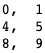

In [37]:
arr3_4[..., :2]

array([[0, 1],
       [4, 5],
       [8, 9]])

# 索引的高级操作

在 NumPy 中还可以使用高级索引方式，比如整数数组索引、布尔索引，以下将对两种种索引方式做详细介绍。

## 整数数组索引

**如何选取**

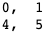

In [39]:
arr3_4[:2, :2]

array([[0, 1],
       [4, 5]])

**获取了 3*4 数组中的四个角上元素，它们对应的行索引是 [0,0] 和 [2,2]，列索引是 [0,3] 和 [0,3]**

In [41]:
arr3_4[[0, 0, 2, 2], [0, 3, 0, 3]].reshape(2, 2)

array([[ 0,  3],
       [ 8, 11]])

## 布尔数组索引

当输出的结果需要经过布尔运算（如比较运算）时，此时会使用到另一种高级索引方式，即布尔数组索引。

In [42]:
arr3_4

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [45]:
arr3_4[arr3_4>6]

array([ 7,  8,  9, 10, 11])

**练习：**

1. 提取数组中所有的奇数
2. 修改奇数数值为-1

In [51]:
x = np.arange(12).reshape(4, 3)
x

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11]])

In [52]:
x[x%2==1]

array([ 1,  3,  5,  7,  9, 11])

In [53]:
x[x%2==1] = -1

In [54]:
x

array([[ 0, -1,  2],
       [-1,  4, -1],
       [ 6, -1,  8],
       [-1, 10, -1]])

# 统计函数

NumPy能方便地求出统计学常见的描述性统计量

In [55]:
arr = np.arange(20).reshape(4, 5)
arr

array([[ 0,  1,  2,  3,  4],
       [ 5,  6,  7,  8,  9],
       [10, 11, 12, 13, 14],
       [15, 16, 17, 18, 19]])

## 求平均值mean()

In [56]:
arr.mean()

9.5

**若想求某一维度的平均值，设置 axis 参数，多维数组的元素指定**

<img src="images/image-20220306224655273.png" />

- axis = 0,将从上往下计算
- axis = 1,将从左往右计算

In [57]:
arr.mean(axis=0)

array([ 7.5,  8.5,  9.5, 10.5, 11.5])

In [58]:
arr.mean(axis=1)

array([ 2.,  7., 12., 17.])

## 中位数 np.median

又称中点数，中值

是按顺序排列的一组数据中居于中间位置的数，代表一个样本、种群或概率分布中的一个数值

- 平均数：是一个"虚拟"的数，是通过计算得到的，它不是数据中的原始数据。中位数：是一个不完全"虚拟"的数。
- 平均数：反映了一组数据的平均大小，常用来一代表数据的总体 "平均水平"。. 中位数：像一条分界线，将数据分成前半部分和后半部分，因此用来代表一组数据的"中等水平"

In [59]:
ar1 = np.array([1, 3, 5, 6, 8])
ar1

array([1, 3, 5, 6, 8])

In [61]:
np.median(ar1)

5.0

In [62]:
ar2 = np.array([1, 3, 5, 6, 7, 8])
ar2

array([1, 3, 5, 6, 7, 8])

In [63]:
np.median(ar2)

5.5

## 求标准差 ndarray.std

在概率统计中最常使用作为统计分布程度上的测量,是反映一组数据离散程度最常用的一种量化形式，是表示精确度的重要指标
- 标准差定义是总体各单位标准值与其平均数离差平方的算术平均数的平方根。

简单来说，标准差是一组数据平均值分散程度的一种度量。
- 一个较大的标准差，代表大部分数值和其平均值之间差异较大；
- 一个较小的标准差，代表这些数值较接近平均值。

In [64]:
'''
例如，A、B两组各有6位学生参加同一次测验，
A组的分数为95、85、75、65、55、45，
B组的分数为73、72、71、69、68、67。
分析那组学生之间的差距大?
'''
a = np.array([95, 85, 75, 65, 55, 45])
b = np.array([73, 72, 71, 69, 68, 67])
print('A组的标准差为:', a.std())
print('B组的标准差为:', b.std())

A组的标准差为: 17.07825127659933
B组的标准差为: 2.160246899469287


## 求最大值ndarray.max()

In [66]:
arr

array([[ 0,  1,  2,  3,  4],
       [ 5,  6,  7,  8,  9],
       [10, 11, 12, 13, 14],
       [15, 16, 17, 18, 19]])

In [67]:
arr.max()

19

In [68]:
arr.max(axis=0)

array([15, 16, 17, 18, 19])

In [69]:
arr.max(axis=1)

array([ 4,  9, 14, 19])

## 求最小值ndarray.min()

In [70]:
arr.min()

0

In [71]:
arr.min(axis=0)

array([0, 1, 2, 3, 4])

In [72]:
arr.min(axis=1)

array([ 0,  5, 10, 15])

## 求和ndarray.sum()

In [73]:
arr.sum()

190

In [74]:
arr.sum(axis=0)

array([30, 34, 38, 42, 46])

In [75]:
arr.sum(axis=1)

array([10, 35, 60, 85])

## 加权平均值 numpy.average()
即将各数值乘以相应的权数，然后加总求和得到总体值，再除以总的单位数

<b>numpy.average(a, axis=None, weights=None, returned=False)</b>

- weights： 数组，可选

    与 a 中的值关联的权重数组。 a 中的每个值都根据其关联的权重对平均值做出贡献。权重数组可以是一维的(在这种情况下，它的长度必须是沿给定轴的 a 的大小)或与 a 具有相同的形状。如果 weights=None，则假定 a 中的所有数据的权重等于 1。一维计算是：

    avg = sum(a * weights) / sum(weights)

    对权重的唯一限制是 sum(weights) 不能为 0。

In [77]:
ar1

array([1, 3, 5, 6, 8])

In [78]:
np.average(ar1)

4.6

In [79]:
np.mean(ar1)

4.6

In [86]:
np.average(ar1, weights=[0.3, 0.2, 0.2, 0.2, 0.1])

3.900000000000001